In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import OrdinalEncoder , StandardScaler
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import  train_test_split
import keras
from keras.models import Sequential
from keras.layers import Dense , Dropout , Flatten

# Dataset Load

In [2]:
df = pd.read_csv("weatherAUS.csv")

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,2017-06-25,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


# Data Prepossesing

In [7]:
df.isna().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [8]:
df['Sunshine'] = df['Sunshine'].fillna(df['Sunshine'].mean())
df['Evaporation'] = df['Evaporation'].fillna(df['Evaporation'].mean())
df['MinTemp'] = df['MinTemp'].fillna(df['MinTemp'].mean())
df['MaxTemp'] = df['MaxTemp'].fillna(df['MaxTemp'].median())
df['Rainfall'] = df['Rainfall'].fillna(df['Rainfall'].median())
df['WindGustDir'] = df['WindGustDir'].fillna(df['WindGustDir'].mode()[0])
df['WindGustSpeed'] = df['WindGustSpeed'].fillna(df['WindGustSpeed'].mode()[0])
df['WindDir9am'] = df['WindDir9am'].fillna(df['WindDir9am'].mode()[0])
df['WindDir3pm'] = df['WindDir3pm'].bfill()
df['WindSpeed3pm'] = df['WindSpeed3pm'].fillna(df['WindSpeed3pm'].mean())
df['WindSpeed9am'] = df['WindSpeed9am'].fillna(df['WindSpeed9am'].mean())
df['Humidity9am'] = df['Humidity9am'].fillna(df['Humidity9am'].mean())
df['WindSpeed3pm'] = df['WindSpeed3pm'].fillna(df['WindSpeed3pm'].mode()[0])
df['Humidity3pm'] = df['Humidity3pm'].fillna(df['Humidity3pm'].mode()[0])
df['Pressure9am'] = df['Pressure9am'].fillna(df['Pressure9am'].mean())
df['Pressure3pm'] = df['Pressure3pm'].fillna(df['Pressure3pm'].mean())
df['Cloud9am'] = df['Cloud9am'].fillna(df['Cloud9am'].median())
df['Cloud3pm'] = df['Cloud3pm'].fillna(df['Cloud3pm'].mean())
df['Temp9am'] = df['Temp9am'].fillna(df['Temp9am'].mean())
df['Temp3pm'] = df['Temp3pm'].fillna(df['Temp3pm'].mean())
df['RainToday'] = df['RainToday'].fillna(df['RainToday'].mode()[0])
df['RainTomorrow'] = df['RainTomorrow'].fillna(df['RainTomorrow'].mode()[0])

Handle all missing values using mean , std, mode, bfill,ffill etc

In [9]:
df.isna().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

There is no nan values aftrer handle it

In [10]:
# Check Duplicate values
df.duplicated().sum()

np.int64(0)

There is no duplicated values present in here

# Data Spliting

In [11]:
x= df.drop(['RainTomorrow'],axis=1)
y= df['RainTomorrow']

# Performing Scalling and Encoding 

In [12]:
std = StandardScaler() # creating object for standerdscaler
ord = OrdinalEncoder() # creating object for ordinalencoder

for col in x.columns:
  if not is_numeric_dtype(x[col]):
    x[col]= ord.fit_transform(x[[col]])
  else:
    x[col]= std.fit_transform(x[[col]]) 

# Performing Train Test split

In [13]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y, test_size=.20, random_state=42)

# Performing ANN

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(64,
                input_dim=22,
                activation="relu",
                kernel_initializer="he_normal"))
model.add(Dropout(0.2))

model.add(Dense(32,
                activation="relu",
                kernel_initializer="he_normal"))
model.add(Dropout(0.2))

model.add(Dense(16,
                activation="relu",
                kernel_initializer="he_normal"))
model.add(Dropout(0.2))

model.add(Dense(1, activation="sigmoid"))

c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics =["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

# Label encode target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ytrain_enc = le.fit_transform(ytrain)
ytest_enc = le.transform(ytest)

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    xtrain, ytrain_enc,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
3273/3273 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7676 - loss: 2.5649 - val_accuracy: 0.7769 - val_loss: 0.5308
Epoch 2/50
3273/3273 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7812 - loss: 0.5303 - val_accuracy: 0.7769 - val_loss: 0.5311
Epoch 3/50
3273/3273 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7816 - loss: 0.5285 - val_accuracy: 0.7769 - val_loss: 0.5326
Epoch 4/50
3273/3273 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7817 - loss: 0.5250 - val_accuracy: 0.7769 - val_loss: 0.5314
Epoch 5/50
3273/3273 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7817 - loss: 0.5255 - val_accuracy: 0.7769 - val_loss: 0.5316
Epoch 6/50
3273/3273 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7817 - loss: 0.5251 - val_accuracy: 0.7769 - val_loss: 0.5311


# Model Evaluation

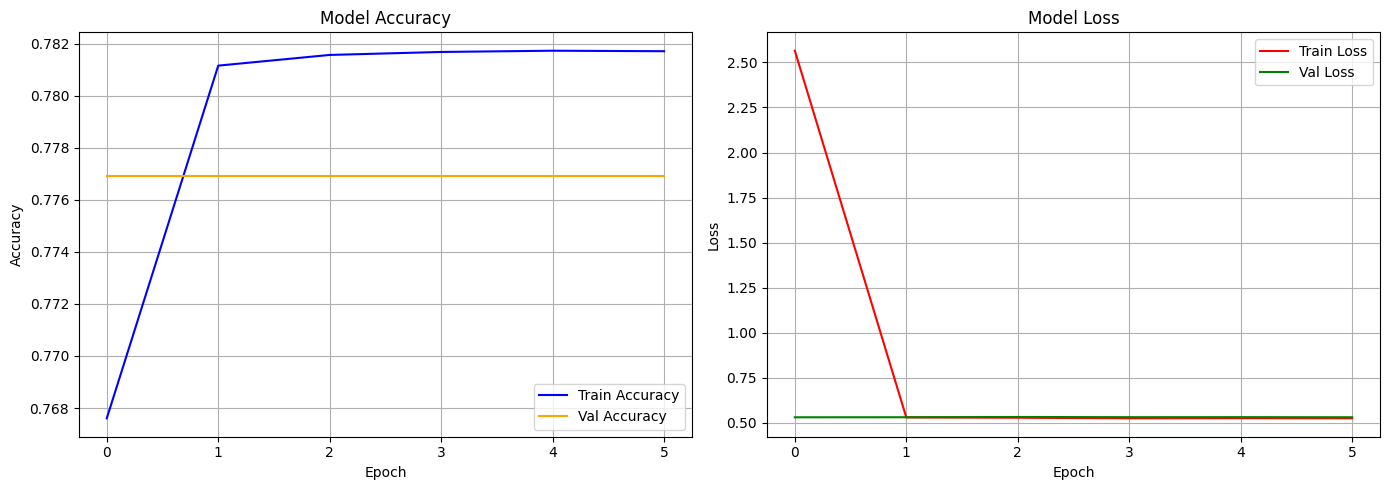

In [17]:
# Plot Training History - Accuracy & Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', color='red')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='green')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [23]:
# Evaluate on test set
loss, accuracy = model.evaluate(xtest, ytest_enc, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Loss     : 0.5278
Test Accuracy : 0.7793 (77.93%)


# Predictions

In [24]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict probabilities and convert to binary (threshold=0.5)
ypred_prob = model.predict(xtest)
ypred = (ypred_prob >= 0.5).astype(int).flatten()

# Decode back to original labels
ypred_labels = le.inverse_transform(ypred)
ytest_labels = ytest.values

910/910 ━━━━━━━━━━━━━━━━━━━━ 1s 592us/step


In [25]:
# Classification Report
print("Classification Report:")
print(classification_report(ytest_labels, ypred_labels, target_names=['No Rain', 'Rain']))

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.78      1.00      0.88     22672
        Rain       0.00      0.00      0.00      6420

    accuracy                           0.78     29092
   macro avg       0.39      0.50      0.44     29092
weighted avg       0.61      0.78      0.68     29092



c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

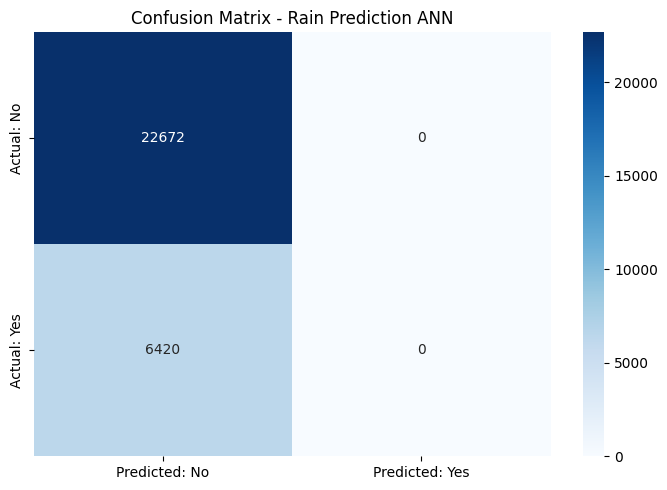

In [26]:
# Confusion Matrix
cm = confusion_matrix(ytest_labels, ypred_labels, labels=['No', 'Yes'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix - Rain Prediction ANN')
plt.tight_layout()
plt.show()

# ROC-AUC Curve

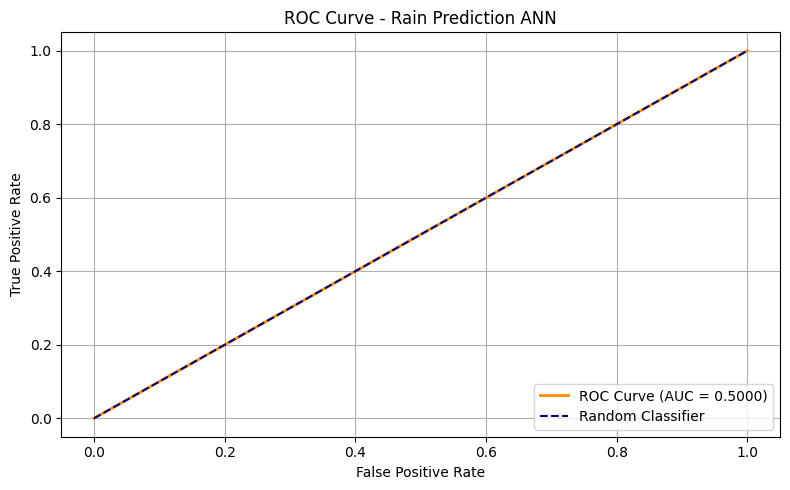

AUC Score: 0.5000


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

# Convert labels to binary for ROC
ytest_bin = (ytest_labels == 'Yes').astype(int)

fpr, tpr, thresholds = roc_curve(ytest_bin, ypred_prob)
auc_score = roc_auc_score(ytest_bin, ypred_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Rain Prediction ANN')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

# Sample Prediction

In [28]:
# Predict rain for a single sample from test set
sample_idx = 0
sample = xtest.iloc[[sample_idx]]
sample_pred_prob = model.predict(sample, verbose=0)[0][0]
sample_pred_label = 'Yes (Rain)' if sample_pred_prob >= 0.5 else 'No (No Rain)'
actual_label = ytest_labels[sample_idx]

print(f"Sample Index   : {sample_idx}")
print(f"Actual Label   : {actual_label}")
print(f"Predicted Label: {sample_pred_label}")
print(f"Rain Probability: {sample_pred_prob:.4f} ({sample_pred_prob*100:.2f}%)")

Sample Index   : 0
Actual Label   : Yes
Predicted Label: No (No Rain)
Rain Probability: 0.2207 (22.07%)
